# 🌫️ Beijing Air Quality — Random Forest Regressor

**Dataset:** 12 estaciones meteorológicas de Beijing (2013–2017)  
**Target:** `PM2.5` — concentración de partículas finas (μg/m³)  
**Modelo:** `RandomForestRegressor` con Pipeline de scikit-learn

---

### Estructura del notebook

```
1. Instalación y imports
2. Carga del RAR y combinación de los 12 CSV
3. Exploración inicial (EDA)
4. Limpieza y preprocesamiento
5. Feature engineering
6. Train / Test split
7. Pipeline: Transformadores + Estimador
8. Entrenamiento
9. Evaluación y métricas
10. Importancia de features
11. Guardar modelo (para Streamlit)
```

### Columnas del dataset
| Columna | Tipo | Descripción |
|---------|------|-------------|
| `No` | int | Índice de fila |
| `year`, `month`, `day`, `hour` | int | Timestamp descompuesto |
| `PM2.5` | float | **TARGET** — partículas finas (μg/m³) |
| `PM10` | float | Partículas gruesas |
| `SO2`, `NO2`, `CO`, `O3` | float | Gases contaminantes |
| `TEMP`, `PRES`, `DEWP` | float | Temperatura, presión, punto de rocío |
| `RAIN` | float | Precipitación |
| `wd` | str | Dirección del viento (16 categorías) |
| `WSPM` | float | Velocidad del viento |
| `station` | str | Nombre de la estación |

---
## Celda 1 — Instalación y imports

In [ ]:
# Instalar rarfile para descomprimir el RAR directamente en Colab
!pip install rarfile -q
!apt-get install -y unrar -q 2>/dev/null || apt-get install -y unar -q

import os
import glob
import zipfile
import rarfile
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import OneHotEncoder, StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.ensemble         import RandomForestRegressor
from sklearn.metrics          import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

# Estilo de gráficos
plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#8b949e',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : 'white',
    'grid.color'       : '#21262d',
    'axes.grid'        : True,
})

SEED = 42
np.random.seed(SEED)

print('✓ Imports OK')

Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
✓ Imports OK


---
## Celda 2 — Subir y descomprimir el RAR

In [ ]:
# ── Subida del archivo RAR desde tu PC ──────────────────────────
from google.colab import files

print('Seleccioná tu archivo .rar con los 12 CSV:')
uploaded = files.upload()
RAR_PATH = list(uploaded.keys())[0]
print(f'✓ Archivo subido: {RAR_PATH}  ({os.path.getsize(RAR_PATH)/1024/1024:.1f} MB)')

Seleccioná tu archivo .rar con los 12 CSV:


Saving PRSA_Data_20130301-20170228.rar to PRSA_Data_20130301-20170228.rar
✓ Archivo subido: PRSA_Data_20130301-20170228.rar  (7.9 MB)


In [ ]:
# ── Descomprimir ─────────────────────────────────────────────────
EXTRACT_DIR = '/content/beijing_data'
os.makedirs(EXTRACT_DIR, exist_ok=True)

try:
    with rarfile.RarFile(RAR_PATH) as rf:
        rf.extractall(EXTRACT_DIR)
    print(f'✓ Descomprimido con rarfile en: {EXTRACT_DIR}')
except Exception as e:
    # Fallback: unrar por sistema
    print(f'  rarfile falló ({e}), usando unrar del sistema...')
    os.system(f'unrar x "{RAR_PATH}" {EXTRACT_DIR}/')

# Listar archivos extraídos
csvs = sorted(glob.glob(os.path.join(EXTRACT_DIR, '**/*.csv'), recursive=True))
if not csvs:
    csvs = sorted(glob.glob(os.path.join(EXTRACT_DIR, '*.csv')))

print(f'\nCSV encontrados: {len(csvs)}')
for f in csvs:
    print(f'  {os.path.basename(f)}')

✓ Descomprimido con rarfile en: /content/beijing_data

CSV encontrados: 12
  PRSA_Data_Aotizhongxin_20130301-20170228.csv
  PRSA_Data_Changping_20130301-20170228.csv
  PRSA_Data_Dingling_20130301-20170228.csv
  PRSA_Data_Dongsi_20130301-20170228.csv
  PRSA_Data_Guanyuan_20130301-20170228.csv
  PRSA_Data_Gucheng_20130301-20170228.csv
  PRSA_Data_Huairou_20130301-20170228.csv
  PRSA_Data_Nongzhanguan_20130301-20170228.csv
  PRSA_Data_Shunyi_20130301-20170228.csv
  PRSA_Data_Tiantan_20130301-20170228.csv
  PRSA_Data_Wanliu_20130301-20170228.csv
  PRSA_Data_Wanshouxigong_20130301-20170228.csv


---
## Celda 3 — Combinar los 12 CSV en un único DataFrame

In [ ]:
def cargar_csv(ruta):
    """
    Carga un CSV del dataset Beijing Air Quality.
    Aplica tipos correctos desde el momento de la carga.
    """
    dtype_map = {
        'No'     : 'int32',
        'year'   : 'int16',
        'month'  : 'int8',
        'day'    : 'int8',
        'hour'   : 'int8',
        'PM2.5'  : 'float32',
        'PM10'   : 'float32',
        'SO2'    : 'float32',
        'NO2'    : 'float32',
        'CO'     : 'float32',
        'O3'     : 'float32',
        'TEMP'   : 'float32',
        'PRES'   : 'float32',
        'DEWP'   : 'float32',
        'RAIN'   : 'float32',
        'WSPM'   : 'float32',
    }
    df = pd.read_csv(ruta, dtype=dtype_map)
    return df


partes = []
for ruta in csvs:
    df_tmp = cargar_csv(ruta)
    partes.append(df_tmp)
    print(f'  {os.path.basename(ruta):<55} {df_tmp.shape}')

df_raw = pd.concat(partes, ignore_index=True)

print(f'\n✓ Dataset combinado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'  Estaciones únicas: {df_raw["station"].unique()}')
print(f'  Memoria RAM       : {df_raw.memory_usage(deep=True).sum()/1024/1024:.1f} MB')

  PRSA_Data_Aotizhongxin_20130301-20170228.csv            (35064, 18)
  PRSA_Data_Changping_20130301-20170228.csv               (35064, 18)
  PRSA_Data_Dingling_20130301-20170228.csv                (35064, 18)
  PRSA_Data_Dongsi_20130301-20170228.csv                  (35064, 18)
  PRSA_Data_Guanyuan_20130301-20170228.csv                (35064, 18)
  PRSA_Data_Gucheng_20130301-20170228.csv                 (35064, 18)
  PRSA_Data_Huairou_20130301-20170228.csv                 (35064, 18)
  PRSA_Data_Nongzhanguan_20130301-20170228.csv            (35064, 18)
  PRSA_Data_Shunyi_20130301-20170228.csv                  (35064, 18)
  PRSA_Data_Tiantan_20130301-20170228.csv                 (35064, 18)
  PRSA_Data_Wanliu_20130301-20170228.csv                  (35064, 18)
  PRSA_Data_Wanshouxigong_20130301-20170228.csv           (35064, 18)

✓ Dataset combinado: 420,768 filas × 18 columnas
  Estaciones únicas: ['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhan

---
## Celda 4 — Exploración inicial (EDA)

In [ ]:
print('=' * 60)
print('  EDA — EXPLORACIÓN INICIAL')
print('=' * 60)

# ── Tipos de datos ───────────────────────────────────────────────
print('\n[1] Tipos de datos:')
print(df_raw.dtypes.to_string())

# ── Nulos ────────────────────────────────────────────────────────
print('\n[2] Valores nulos:')
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(2)
df_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje_%': pct})
df_nulos = df_nulos[df_nulos['nulos'] > 0]
print(df_nulos.to_string())

# ── Estadísticas ─────────────────────────────────────────────────
print('\n[3] Estadísticas descriptivas (numéricas):')
print(df_raw.describe().round(2).to_string())

# ── Categorías ───────────────────────────────────────────────────
print('\n[4] Dirección del viento (wd) — valores únicos:')
print(df_raw['wd'].value_counts().to_string())

print('\n✓ EDA completado')

  EDA — EXPLORACIÓN INICIAL

[1] Tipos de datos:
No           int32
year         int16
month         int8
day           int8
hour          int8
PM2.5      float32
PM10       float32
SO2        float32
NO2        float32
CO         float32
O3         float32
TEMP       float32
PRES       float32
DEWP       float32
RAIN       float32
wd          object
WSPM       float32
station     object

[2] Valores nulos:
       nulos  porcentaje_%
PM2.5   8739          2.08
PM10    6449          1.53
SO2     9021          2.14
NO2    12116          2.88
CO     20701          4.92
O3     13277          3.16
TEMP     398          0.09
PRES     393          0.09
DEWP     403          0.10
RAIN     390          0.09
wd      1822          0.43
WSPM     318          0.08

[3] Estadísticas descriptivas (numéricas):
              No       year      month        day       hour      PM2.5       PM10        SO2        NO2         CO         O3       TEMP       PRES       DEWP       RAIN       WSPM
count  42076

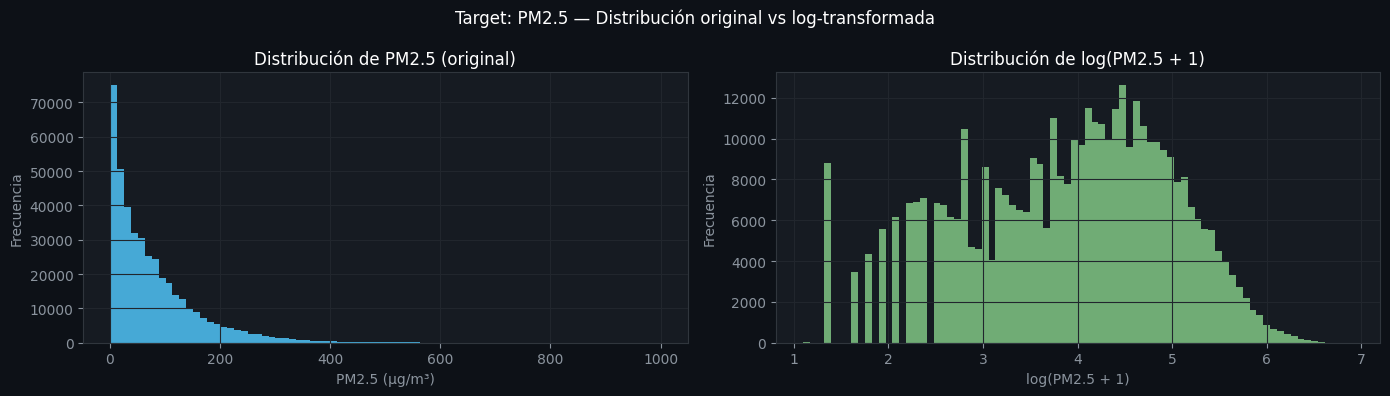

In [ ]:
# ── Gráfico 1: distribución del target PM2.5 ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['PM2.5'].dropna(), bins=80,
             color='#4fc3f7', edgecolor='none', alpha=0.85)
axes[0].set_title('Distribución de PM2.5 (original)')
axes[0].set_xlabel('PM2.5 (μg/m³)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df_raw['PM2.5'].dropna()), bins=80,
             color='#81c784', edgecolor='none', alpha=0.85)
axes[1].set_title('Distribución de log(PM2.5 + 1)')
axes[1].set_xlabel('log(PM2.5 + 1)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Target: PM2.5 — Distribución original vs log-transformada',
             color='white', fontsize=12)
plt.tight_layout()
plt.savefig('dist_pm25.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
# Nota: el target tiene cola larga a la derecha → vamos a aplicar log1p

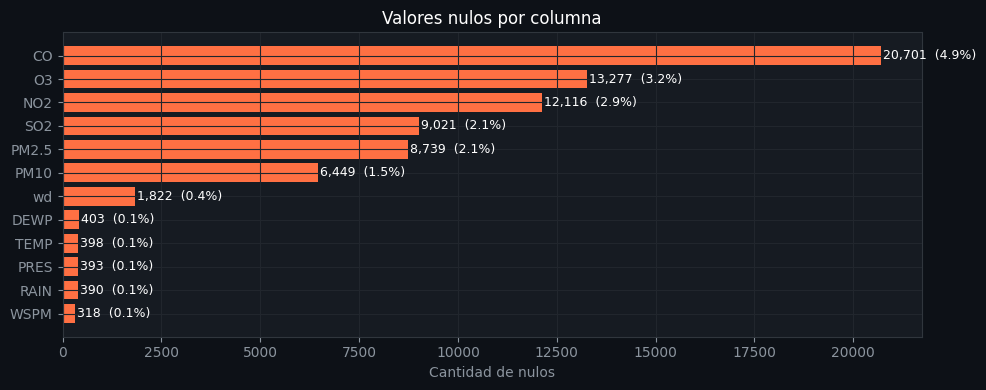

In [ ]:
# ── Gráfico 2: nulos por columna ─────────────────────────────────
nulos_col = df_raw.isnull().sum()
nulos_col = nulos_col[nulos_col > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(nulos_col.index, nulos_col.values,
               color='#ff7043', edgecolor='none')
for bar, v in zip(bars, nulos_col.values):
    ax.text(v + 50, bar.get_y() + bar.get_height()/2,
            f'{v:,}  ({v/len(df_raw)*100:.1f}%)',
            va='center', color='white', fontsize=9)
ax.set_title('Valores nulos por columna')
ax.set_xlabel('Cantidad de nulos')
plt.tight_layout()
plt.savefig('nulos.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

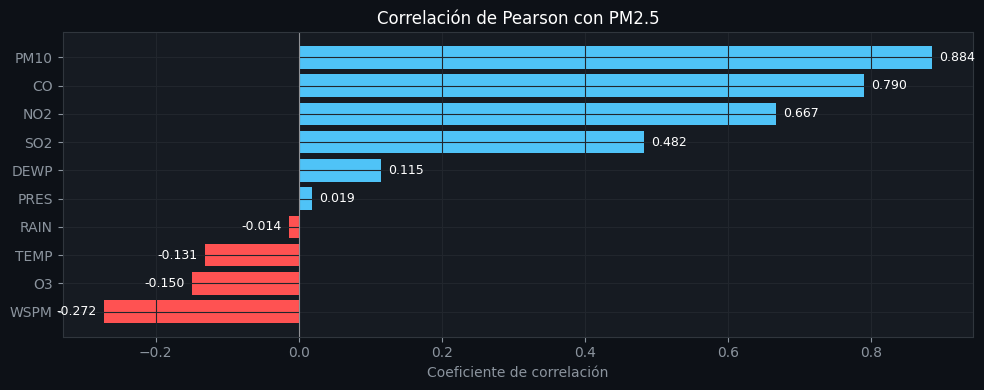

In [ ]:
# ── Gráfico 3: correlación con PM2.5 ─────────────────────────────
cols_num = ['PM2.5','PM10','SO2','NO2','CO','O3',
            'TEMP','PRES','DEWP','RAIN','WSPM']
corr = df_raw[cols_num].corr()['PM2.5'].drop('PM2.5').sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
colores = ['#ff5252' if v < 0 else '#4fc3f7' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colores, edgecolor='none')
ax.axvline(0, color='white', linewidth=0.8, alpha=0.5)
for bar, v in zip(bars, corr.values):
    ax.text(v + 0.01 if v >= 0 else v - 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center',
            ha='left' if v >= 0 else 'right',
            color='white', fontsize=9)
ax.set_title('Correlación de Pearson con PM2.5')
ax.set_xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Celda 5 — Limpieza y corrección de tipos

### Decisiones de limpieza

| Problema | Columna | Solución |
|----------|---------|----------|
| Columna inútil | `No` | Eliminar |
| Columna constante | `station` | Conservar como feature categórico (útil en Streamlit para predecir por estación) |
| Nulos en **target** `PM2.5` | 2.21% | Eliminar esas filas (no se puede imputar el target) |
| Nulos en **features numéricos** | hasta 4.3% (CO) | Imputar con mediana dentro del Pipeline |
| Nulos en `wd` | 0.40% | Imputar con moda dentro del Pipeline |
| Outliers extremos | PM2.5 > 500, CO > 8000 | Cap en percentil 99.5 |
| Tipos subóptimos | year/month/day/hour | Convertir a int |
| Timestamp descompuesto | year+month+day+hour | Construir datetime + features cíclicos |

In [ ]:
df = df_raw.copy()

# ── 1. Eliminar columna índice ───────────────────────────────────
df.drop(columns=['No'], inplace=True)
print('✓ Columna No eliminada')

# ── 2. Construir timestamp y eliminar columnas temporales ────────
df['datetime'] = pd.to_datetime(
    df[['year','month','day','hour']].rename(
        columns={'year':'year','month':'month','day':'day','hour':'hour'}
    )
)
print(f'✓ Columna datetime creada: {df["datetime"].min()} → {df["datetime"].max()}')

# ── 3. Eliminar filas donde el TARGET es nulo ────────────────────
n_antes = len(df)
df.dropna(subset=['PM2.5'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'✓ Filas con PM2.5 nulo eliminadas: {n_antes - len(df):,} → quedan {len(df):,} filas')

# ── 4. Cap de outliers en percentil 99.5 ────────────────────────
cols_cap = ['PM2.5','PM10','SO2','NO2','CO','O3','WSPM','RAIN']
for col in cols_cap:
    cap = df[col].quantile(0.995)
    n_cap = (df[col] > cap).sum()
    df[col] = df[col].clip(upper=cap)
    if n_cap > 0:
        print(f'  Cap {col:<8}: {n_cap:4d} valores → {cap:.1f}')
print('✓ Cap de outliers aplicado (p99.5)')

# ── 5. Verificar tipos finales ───────────────────────────────────
print('\nTipos de datos finales:')
print(df.dtypes.to_string())

print(f'\n✓ Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✓ Columna No eliminada
✓ Columna datetime creada: 2013-03-01 00:00:00 → 2017-02-28 23:00:00
✓ Filas con PM2.5 nulo eliminadas: 8,739 → quedan 412,029 filas
  Cap PM2.5   : 2049 valores → 432.0
  Cap PM10    : 2054 valores → 493.0
  Cap SO2     : 1984 valores → 123.0
  Cap NO2     : 1928 valores → 173.0
  Cap CO      : 1919 valores → 7000.0
  Cap O3      : 1978 valores → 265.0
  Cap WSPM    : 1810 valores → 6.8
  Cap RAIN    : 2009 valores → 2.9
✓ Cap de outliers aplicado (p99.5)

Tipos de datos finales:
year                 int16
month                 int8
day                   int8
hour                  int8
PM2.5              float32
PM10               float32
SO2                float32
NO2                float32
CO                 float32
O3                 float32
TEMP               float32
PRES               float32
DEWP               float32
RAIN               float32
wd                  object
WSPM               float32
station             object
datetime    datetime64[ns]

✓ Da

---
## Celda 6 — Feature Engineering

In [ ]:
# ── Features cíclicos ────────────────────────────────────────────
# Hora, mes y día de la semana son variables cíclicas:
# la hora 23 es 'cercana' a la hora 0, no 'lejana'.
# Se codifican con sin/cos para preservar esa circularidad.

df['hora_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
df['hora_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
df['mes_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['mes_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['dow']       = df['datetime'].dt.dayofweek        # 0=lunes ... 6=domingo
df['dow_sin']   = np.sin(2 * np.pi * df['dow']   / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['dow']   / 7)

# ── Feature: estación del año ────────────────────────────────────
def estacion_anio(m):
    if m in [12, 1, 2]:  return 'winter'
    if m in [3, 4, 5]:   return 'spring'
    if m in [6, 7, 8]:   return 'summer'
    return 'autumn'

df['season'] = df['month'].apply(estacion_anio)

# ── Feature: temperatura real del termómetro (TEMP - DEWP) ──────
# El spread entre temperatura y punto de rocío mide sequedad del aire
df['temp_dewp_diff'] = df['TEMP'] - df['DEWP']

# ── Feature: log de contaminantes (para reducir asimetría) ──────
for col in ['CO', 'SO2', 'NO2']:
    df[f'log_{col}'] = np.log1p(df[col])

print('Features generados:')
nuevas = ['hora_sin','hora_cos','mes_sin','mes_cos',
          'dow','dow_sin','dow_cos','season',
          'temp_dewp_diff','log_CO','log_SO2','log_NO2']
for f in nuevas:
    print(f'  ✓ {f}')

print(f'\nTotal columnas: {df.shape[1]}')

Features generados:
  ✓ hora_sin
  ✓ hora_cos
  ✓ mes_sin
  ✓ mes_cos
  ✓ dow
  ✓ dow_sin
  ✓ dow_cos
  ✓ season
  ✓ temp_dewp_diff
  ✓ log_CO
  ✓ log_SO2
  ✓ log_NO2

Total columnas: 30


---
## Celda 7 — Definir features y target / Train-Test Split

In [ ]:
# ── Target ───────────────────────────────────────────────────────
# Aplicamos log1p para distribución más simétrica.
# Al evaluar deshacemos con expm1.
TARGET     = 'PM2.5'
y_original = df[TARGET].values.astype(np.float32)
y          = np.log1p(y_original)   # log(PM2.5 + 1)

# ── Features a usar ──────────────────────────────────────────────
EXCLUIR  = ['PM2.5', 'datetime', 'year', 'month', 'day', 'hour', 'dow']
FEATURES = [c for c in df.columns if c not in EXCLUIR]
X = df[FEATURES].copy()

# ── Asegurar que columnas string sean dtype object (pandas 2.x) ──
# En pandas 2.x el dtype 'str' no es válido en select_dtypes,
# solo 'object'. Convertimos explícitamente las columnas categóricas.
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('object')

# Si 'season' quedó como StringDtype, lo convertimos a object
if 'season' in X.columns:
    X['season'] = X['season'].astype('object')
if 'wd' in X.columns:
    X['wd'] = X['wd'].astype('object')

# ── Separar numéricas y categóricas ──────────────────────────────
# NOTA: En pandas 2.x 'str' ya no es un alias válido de dtype.
#       Solo usar 'object' para strings/categorías.
COLS_NUM = X.select_dtypes(
    include=['float32','float64','int8','int16','int32','int64','number']
).columns.tolist()

COLS_CAT = X.select_dtypes(
    include=['object','category']
).columns.tolist()

print('Features numéricos  :', COLS_NUM)
print('Features categóricos:', COLS_CAT)
print(f'\nTotal features: {len(FEATURES)}')
print(f'  → numéricos  : {len(COLS_NUM)}')
print(f'  → categóricos: {len(COLS_CAT)}')

# ── Train / Test Split TEMPORAL (no aleatorio) ───────────────────
# Los datos son una serie de tiempo: entrenamos con el pasado
# y evaluamos con el futuro. NO usar train_test_split aleatorio.
orden   = df['datetime'].argsort().values
X_ord   = X.iloc[orden].reset_index(drop=True)
y_ord   = y[orden]

split_idx       = int(len(X_ord) * 0.80)
X_train, X_test = X_ord.iloc[:split_idx], X_ord.iloc[split_idx:]
y_train, y_test = y_ord[:split_idx],       y_ord[split_idx:]

print(f'\n✓ Split temporal 80/20:')
print(f'  Train : {X_train.shape[0]:>8,} filas')
print(f'  Test  : {X_test.shape[0]:>8,} filas')
print(f'  Ratio : {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0]):.1%} / {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]):.1%}')


Features numéricos  : ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'hora_sin', 'hora_cos', 'mes_sin', 'mes_cos', 'dow_sin', 'dow_cos', 'temp_dewp_diff', 'log_CO', 'log_SO2', 'log_NO2']
Features categóricos: ['wd', 'station', 'season']

Total features: 23
  → numéricos  : 20
  → categóricos: 3

✓ Split temporal 80/20:
  Train :  329,623 filas
  Test  :   82,406 filas
  Ratio : 80.0% / 20.0%


---
## Celda 8 — Pipeline: Transformadores + Estimador

```
Pipeline
  └── preprocessor  (ColumnTransformer)
        ├── num_transformer
        │     ├── SimpleImputer(strategy='median')   ← imputa nulos
        │     └── StandardScaler()                    ← escala [μ=0, σ=1]
        └── cat_transformer
              ├── SimpleImputer(strategy='most_frequent')  ← imputa nulos en 'wd'
              └── OneHotEncoder(handle_unknown='ignore')   ← codifica categorías
  └── regressor
        └── RandomForestRegressor(n_estimators=200, ...)
```

In [ ]:
# ── Transformador numérico ───────────────────────────────────────
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # nulos → mediana
    ('scaler',  StandardScaler()),                   # normaliza
])

# ── Transformador categórico ─────────────────────────────────────
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # nulos → moda
    ('encoder', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False)),       # OHE
])

# ── Preprocesador combinado ──────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, COLS_NUM),
    ('cat', cat_transformer, COLS_CAT),
], remainder='drop')

# ── Estimador ────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators      = 200,    # cantidad de árboles
    max_depth         = 20,     # profundidad máxima
    min_samples_leaf  = 4,      # mínimo de muestras por hoja
    min_samples_split = 8,      # mínimo para hacer un split
    max_features      = 0.5,    # features aleatorios por split (50%)
    n_jobs            = -1,     # todos los núcleos
    random_state      = SEED,
    oob_score         = True,   # out-of-bag score (validación sin test set)
)

# ── Pipeline completo ────────────────────────────────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',    rf),
])

print('Pipeline construido:')
print(pipeline)

Pipeline construido:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['PM10', 'SO2', 'NO2', 'CO',
                                                   'O3', 'TEMP', 'PRES', 'DEWP',
                                                   'RAIN', 'WSPM', 'hora_sin',
                                                   'hora_cos', 'mes_sin',
                                                   'mes_cos', 'dow_sin',
                                                   'dow_cos', 'temp_dewp_diff',
                                                   'log_CO', 'log_SO2',
      

---
## Celda 9 — Entrenamiento

In [ ]:
import time

print('Entrenando Random Forest...  (puede tardar 2-5 minutos en Colab)')
t0 = time.time()

pipeline.fit(X_train, y_train)

t_total = time.time() - t0
print(f'✓ Entrenamiento completado en {t_total:.1f} segundos')
print(f'  OOB R² score: {pipeline.named_steps["regressor"].oob_score_:.4f}')

Entrenando Random Forest...  (puede tardar 2-5 minutos en Colab)
✓ Entrenamiento completado en 99.1 segundos
  OOB R² score: 0.9263


---
## Celda 10 — Evaluación y métricas

In [ ]:
# Predicciones en escala log
y_pred_log_train = pipeline.predict(X_train)
y_pred_log_test  = pipeline.predict(X_test)

# Revertir log1p → escala original (μg/m³)
y_pred_train = np.expm1(y_pred_log_train)
y_pred_test  = np.expm1(y_pred_log_test)
y_true_train = np.expm1(y_train)
y_true_test  = np.expm1(y_test)

def metricas(y_true, y_pred, nombre):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'  {nombre}')
    print(f'    MAE  (error absoluto medio)    : {mae:.2f}  μg/m³')
    print(f'    RMSE (raíz error cuadrático)   : {rmse:.2f}  μg/m³')
    print(f'    MAPE (error porcentual medio)  : {mape:.2f}  %')
    print(f'    R²   (coef. determinación)     : {r2:.4f}')
    return mae, rmse, r2, mape

print('=' * 55)
print('  EVALUACIÓN — ESCALA ORIGINAL (μg/m³)')
print('=' * 55)
metricas(y_true_train, y_pred_train, 'TRAIN')
print()
metricas(y_true_test,  y_pred_test,  'TEST')

  EVALUACIÓN — ESCALA ORIGINAL (μg/m³)
  TRAIN
    MAE  (error absoluto medio)    : 7.32  μg/m³
    RMSE (raíz error cuadrático)   : 12.47  μg/m³
    MAPE (error porcentual medio)  : 15.66  %
    R²   (coef. determinación)     : 0.9746

  TEST
    MAE  (error absoluto medio)    : 12.00  μg/m³
    RMSE (raíz error cuadrático)   : 19.41  μg/m³
    MAPE (error porcentual medio)  : 26.14  %
    R²   (coef. determinación)     : 0.9417


(11.999306072148675,
 np.float64(19.414621021985678),
 0.9416695539245779,
 26.13584010799214)

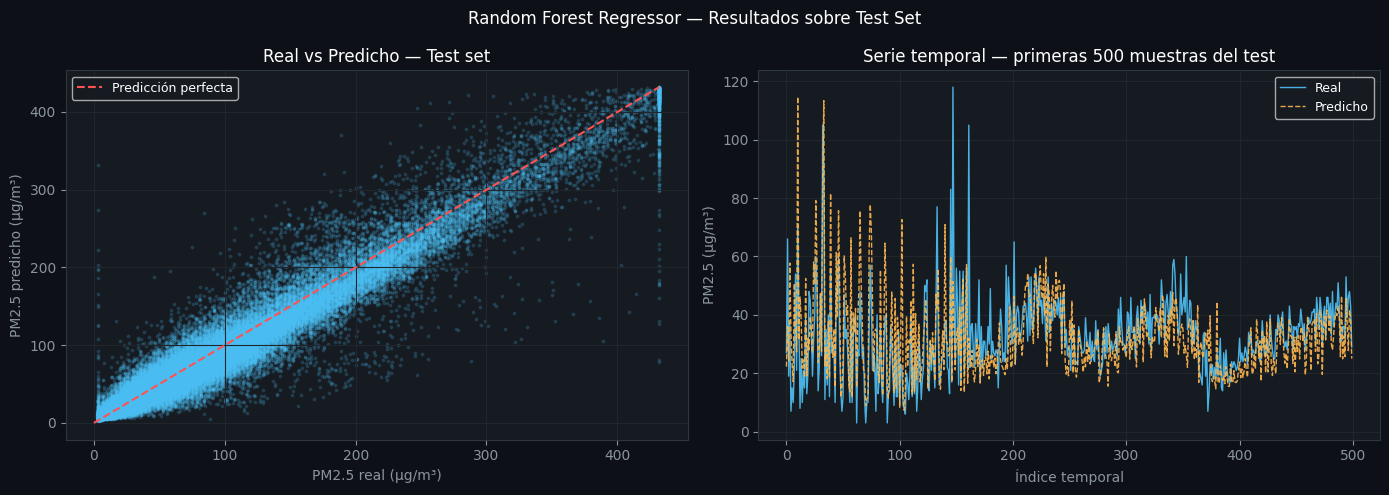

In [ ]:
# ── Gráfico: Real vs Predicho (test set) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter real vs predicho
max_val = max(y_true_test.max(), y_pred_test.max())
axes[0].scatter(y_true_test, y_pred_test,
                alpha=0.15, s=3, color='#4fc3f7')
axes[0].plot([0, max_val], [0, max_val],
             color='#ff5252', linewidth=1.5, linestyle='--',
             label='Predicción perfecta')
axes[0].set_xlabel('PM2.5 real (μg/m³)')
axes[0].set_ylabel('PM2.5 predicho (μg/m³)')
axes[0].set_title('Real vs Predicho — Test set')
axes[0].legend(fontsize=9)

# Serie temporal: primeras 500 predicciones
n_show = 500
axes[1].plot(y_true_test[:n_show],
             label='Real', color='#4fc3f7', linewidth=1, alpha=0.9)
axes[1].plot(y_pred_test[:n_show],
             label='Predicho', color='#ffb74d',
             linewidth=1, alpha=0.9, linestyle='--')
axes[1].set_xlabel('Índice temporal')
axes[1].set_ylabel('PM2.5 (μg/m³)')
axes[1].set_title(f'Serie temporal — primeras {n_show} muestras del test')
axes[1].legend(fontsize=9)

plt.suptitle('Random Forest Regressor — Resultados sobre Test Set',
             color='white', fontsize=12)
plt.tight_layout()
plt.savefig('resultados_test.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

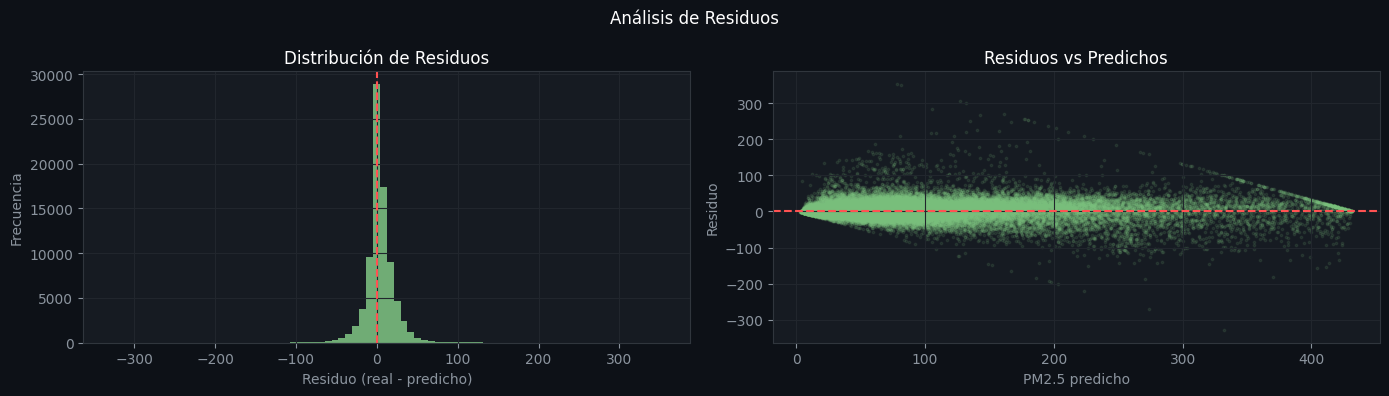

  Media de residuos : 3.756  (idealmente ≈ 0)
  Std de residuos   : 19.048


In [ ]:
# ── Gráfico: distribución de residuos ────────────────────────────
residuos = y_true_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuos, bins=80, color='#81c784',
             edgecolor='none', alpha=0.85)
axes[0].axvline(0, color='#ff5252', linewidth=1.5, linestyle='--')
axes[0].set_title('Distribución de Residuos')
axes[0].set_xlabel('Residuo (real - predicho)')
axes[0].set_ylabel('Frecuencia')

axes[1].scatter(y_pred_test, residuos,
                alpha=0.1, s=3, color='#81c784')
axes[1].axhline(0, color='#ff5252', linewidth=1.5, linestyle='--')
axes[1].set_title('Residuos vs Predichos')
axes[1].set_xlabel('PM2.5 predicho')
axes[1].set_ylabel('Residuo')

plt.suptitle('Análisis de Residuos', color='white', fontsize=12)
plt.tight_layout()
plt.savefig('residuos.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'  Media de residuos : {residuos.mean():.3f}  (idealmente ≈ 0)')
print(f'  Std de residuos   : {residuos.std():.3f}')

---
## Celda 11 — Importancia de features

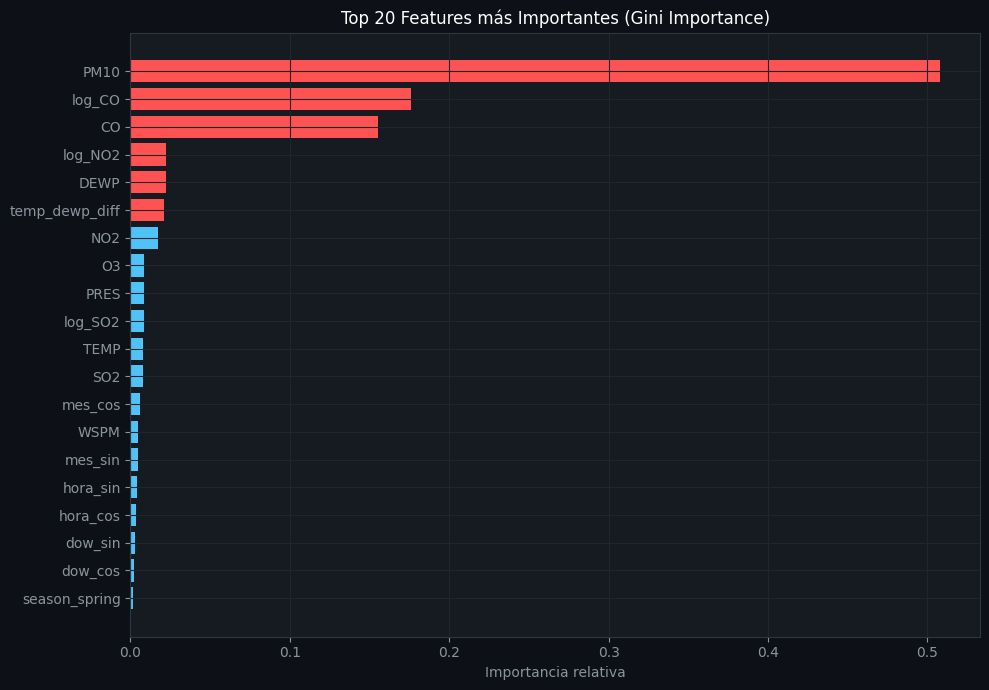


Top 20:
PM10              0.507627
log_CO            0.175970
CO                0.155594
log_NO2           0.022155
DEWP              0.022091
temp_dewp_diff    0.020973
NO2               0.017024
O3                0.008524
PRES              0.008392
log_SO2           0.008276
TEMP              0.007854
SO2               0.007816
mes_cos           0.005909
WSPM              0.004852
mes_sin           0.004582
hora_sin          0.003957
hora_cos          0.003565
dow_sin           0.002984
dow_cos           0.002006
season_spring     0.001348


In [ ]:
# Recuperar nombres de features después del Pipeline
rf_model = pipeline.named_steps['regressor']
prep     = pipeline.named_steps['preprocessor']

# Nombres OHE
ohe_names = prep.named_transformers_['cat']['encoder'].get_feature_names_out(COLS_CAT)
all_names = COLS_NUM + list(ohe_names)

importancias = pd.Series(
    rf_model.feature_importances_,
    index=all_names
).sort_values(ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
top = importancias.head(top_n)
colors = ['#ff5252' if i < 6 else '#4fc3f7' for i in range(len(top))]
ax.barh(top.index[::-1], top.values[::-1],
        color=colors[::-1], edgecolor='none')
ax.set_title(f'Top {top_n} Features más Importantes (Gini Importance)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'\nTop {top_n}:')
print(importancias.head(top_n).to_string())

---
## Celda 12 — Guardar modelo y artefactos para Streamlit

In [ ]:
import json

MODEL_DIR = '/content/modelo_beijing'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── 1. Pipeline completo (preprocesador + modelo) ────────────────
joblib.dump(pipeline, os.path.join(MODEL_DIR, 'pipeline_rf.pkl'))
print('✓ pipeline_rf.pkl guardado')

# ── 2. Metadatos del modelo (para Streamlit) ─────────────────────
metricas_test = {
    'MAE'  : float(mean_absolute_error(y_true_test, y_pred_test)),
    'RMSE' : float(np.sqrt(mean_squared_error(y_true_test, y_pred_test))),
    'R2'   : float(r2_score(y_true_test, y_pred_test)),
    'MAPE' : float(mean_absolute_percentage_error(y_true_test, y_pred_test) * 100),
}

metadata = {
    'target'           : TARGET,
    'target_transform' : 'log1p',
    'features'         : FEATURES,
    'cols_num'         : COLS_NUM,
    'cols_cat'         : COLS_CAT,
    'n_train'          : int(X_train.shape[0]),
    'n_test'           : int(X_test.shape[0]),
    'metricas_test'    : metricas_test,
    'oob_r2'           : float(rf_model.oob_score_),
    'estaciones'       : list(df['station'].unique()),
    'wd_categorias'    : list(df['wd'].dropna().unique()),
}

with open(os.path.join(MODEL_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)
print('✓ metadata.json guardado')

# ── 3. Importancias como CSV ─────────────────────────────────────
importancias.reset_index().rename(
    columns={'index':'feature', 0:'importancia'}
).to_csv(os.path.join(MODEL_DIR, 'feature_importance.csv'), index=False)
print('✓ feature_importance.csv guardado')

# ── 4. Descargar a tu PC ─────────────────────────────────────────
import shutil
zip_path = '/content/modelo_beijing.zip'
shutil.make_archive('/content/modelo_beijing', 'zip', MODEL_DIR)
files.download(zip_path)
print('\n✓ modelo_beijing.zip descargado en tu PC')
print('  Contenido:')
for f in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'    {f}  ({size:.0f} KB)')

✓ pipeline_rf.pkl guardado
✓ metadata.json guardado
✓ feature_importance.csv guardado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ modelo_beijing.zip descargado en tu PC
  Contenido:
    pipeline_rf.pkl  (882539 KB)
    feature_importance.csv  (2 KB)
    metadata.json  (1 KB)


---
## Celda 13 — Resumen final

In [ ]:
print('=' * 60)
print('  RESUMEN FINAL')
print('=' * 60)
print(f'  Dataset         : {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'  Estaciones      : {len(df["station"].unique())}')
print(f'  Período         : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'  Features usados : {len(FEATURES)}  ({len(COLS_NUM)} numéricos + {len(COLS_CAT)} categóricos)')
print(f'  Split           : 80% train / 20% test (temporal)')
print(f'  Train           : {X_train.shape[0]:,} filas')
print(f'  Test            : {X_test.shape[0]:,} filas')
print()
print('  Modelo: RandomForestRegressor')
print(f'    n_estimators  : {rf_model.n_estimators}')
print(f'    max_depth     : {rf_model.max_depth}')
print(f'    OOB R²        : {rf_model.oob_score_:.4f}')
print()
print('  Métricas en TEST (escala original μg/m³):')
print(f'    MAE  : {metricas_test["MAE"]:.2f}')
print(f'    RMSE : {metricas_test["RMSE"]:.2f}')
print(f'    MAPE : {metricas_test["MAPE"]:.2f}%')
print(f'    R²   : {metricas_test["R2"]:.4f}')
print()
print('  Archivos guardados:')
print('    pipeline_rf.pkl       ← modelo completo para Streamlit')
print('    metadata.json         ← info del modelo para la app')
print('    feature_importance.csv')
print('=' * 60)

  RESUMEN FINAL
  Dataset         : 412,029 filas × 30 columnas
  Estaciones      : 12
  Período         : 2013-03-01 → 2017-02-28
  Features usados : 23  (20 numéricos + 3 categóricos)
  Split           : 80% train / 20% test (temporal)
  Train           : 329,623 filas
  Test            : 82,406 filas

  Modelo: RandomForestRegressor
    n_estimators  : 200
    max_depth     : 20
    OOB R²        : 0.9263

  Métricas en TEST (escala original μg/m³):
    MAE  : 12.00
    RMSE : 19.41
    MAPE : 26.14%
    R²   : 0.9417

  Archivos guardados:
    pipeline_rf.pkl       ← modelo completo para Streamlit
    metadata.json         ← info del modelo para la app
    feature_importance.csv
